# ⚽ Proyek Portofolio: Dynamic World Cup 2026 Prediction Pipeline
**Oleh:** Fridoom  
**Konteks:** End-to-End Predictive Analytics (Data Ingestion, Dynamic Feature Engineering, and Machine Learning Inference)

Proyek ini membangun sistem prediksi dinamis untuk Piala Dunia 2026 menggunakan alur kerja Data Science yang komprehensif:
1. **Data Collection:** Harvester otomatis menggunakan Open Dataset & Live API Football-Data.org.
2. **Feature Engineering:** Perhitungan metrik sepak bola dinamis (Dynamic Elo Rating & Rolling Form).
3. **Machine Learning Modeling:** - Klasifikasi Probabilitas Hasil Akhir (Home Win, Draw, Away Win) menggunakan `RandomForestClassifier`.
   - Regresi Probabilitas Skor Akurat (*Exact Scoreline*) menggunakan *Poisson Regression Link Function*.
4. **Evaluation & Retraining Loop:** Simulasi adaptasi turnamen tanpa kebocoran data (*data leakage*).

In [1]:
# ==========================================
# 1. SETUP & IMPORTS
# ==========================================
import os
import io
import argparse
from datetime import datetime
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.stats import poisson
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import joblib

# Load API Token dari file .env lokal Anda
load_dotenv()
API_TOKEN = os.environ.get("FOOTBALL_DATA_API_TOKEN")

# Setup folder output agar direktori tetap rapi
DATA_RAW_PATH = "data/raw"
DATA_LOGS_PATH = "data/tournament_logs"
MODELS_PATH = "models"
PLOTS_PATH = "plots"

for path in [DATA_RAW_PATH, DATA_LOGS_PATH, MODELS_PATH, PLOTS_PATH]:
    os.makedirs(path, exist_ok=True)

print("[Setup] Environment siap. Semua direktori output telah dikonfigurasi.")

[Setup] Environment siap. Semua direktori output telah dikonfigurasi.


In [2]:
# ==========================================
# 2. DATA COLLECTION & INGESTION
# ==========================================
HISTORICAL_DATA_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

def _api_headers():
    if not API_TOKEN:
        print("[Scraper] WARNING: Token API tidak diatur. Menggunakan fallback dummy data.")
        return None
    return {"X-Auth-Token": API_TOKEN}

def get_upcoming_matches(competition_id="WC"):
    """Mengambil jadwal pertandingan yang akan datang dari API resmi."""
    print(f"[Scraper] Mengambil pertandingan mendatang untuk kompetisi: {competition_id}")
    headers = _api_headers()
    if headers:
        url = f"https://api.football-data.org/v4/competitions/{competition_id}/matches?status=SCHEDULED"
        try:
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status()
            data = response.json()
            parsed = [
                {
                    "match_id": f"M_{m['id']}",
                    "date": m["utcDate"][:10],
                    "home_team": m["homeTeam"]["name"],
                    "away_team": m["awayTeam"]["name"],
                    "competition_id": 2000,
                } for m in data.get("matches", [])
            ]
            df = pd.DataFrame(parsed)
            if not df.empty:
                df["date"] = pd.to_datetime(df["date"])
                return df
        except Exception as e:
            print(f"[Scraper] Gagal mengambil dari Live API: {e}. Menggunakan fallback.")
    
    # Fallback Data jika API mati atau token belum diisi
    return pd.DataFrame([
        {"match_id": "M_fallback_1", "date": pd.to_datetime("2026-06-20"), "home_team": "Spain", "away_team": "Germany", "competition_id": 2000},
        {"match_id": "M_fallback_2", "date": pd.to_datetime("2026-06-21"), "home_team": "Argentina", "away_team": "France", "competition_id": 2000}
    ])

def get_past_match_results(start_date="2022-01-01", end_date=None):
    """Menggabungkan data historis global dengan data pertandingan Piala Dunia yang sudah selesai."""
    if end_date is None:
        end_date = datetime.now().strftime("%Y-%m-%d")
        
    all_results = []
    try:
        print("[Scraper] Mengunduh dataset historis sepak bola internasional...")
        res = requests.get(HISTORICAL_DATA_URL, timeout=10)
        if res.status_code == 200:
            hist_df = pd.read_csv(io.StringIO(res.text))
            hist_df["date"] = pd.to_datetime(hist_df["date"])
            hist_df = hist_df[(hist_df["date"] >= start_date) & (hist_df["date"] <= end_date)].dropna()
            for idx, r in hist_df.iterrows():
                all_results.append({
                    "match_id": f"M_hist_{idx}", "date": r["date"].strftime("%Y-%m-%d"),
                    "home_team": r["home_team"], "away_team": r["away_team"],
                    "home_score": int(r["home_score"]), "away_score": int(r["away_score"]),
                    "competition_id": 2000
                })
    except Exception as e:
        print(f"[Scraper] Gagal mengambil dataset open-source: {e}")

    df = pd.DataFrame(all_results)
    if not df.empty:
        df["date"] = pd.to_datetime(df["date"])
        df = df.sort_values("date").reset_index(drop=True)
    return df

print("[Scraper] Fungsi pengumpulan data berhasil didefinisikan.")

[Scraper] Fungsi pengumpulan data berhasil didefinisikan.


In [3]:
# ==========================================
# 3. FEATURE ENGINEERING (ELO & ROLLING FORM)
# ==========================================
class EloRatingSystem:
    def __init__(self, default_elo=1500, k_factor=30):
        self.ratings = {}
        self.default_elo = default_elo
        self.k_factor = k_factor

    def get_rating(self, team):
        if team not in self.ratings:
            self.ratings[team] = self.default_elo
        return self.ratings[team]

    def update_ratings(self, home_team, away_team, home_score, away_score):
        r_home = self.get_rating(home_team)
        r_away = self.get_rating(away_team)
        
        # Probabilitas ekspektasi hasil berdasarkan perbedaan rating awal
        e_home = 1 / (1 + 10 ** ((r_away - r_home) / 400))
        e_away = 1 / (1 + 10 ** ((r_home - r_away) / 400))
        
        # Tentukan nilai aktual hasil laga (1 = Menang, 0.5 = Seri, 0 = Kalah)
        if home_score > away_score:
            s_home, s_away = 1.0, 0.0
        elif home_score < away_score:
            s_home, s_away = 0.0, 1.0
        else:
            s_home, s_away = 0.5, 0.5
            
        # Perbarui peta kekuatan Elo tim
        self.ratings[home_team] = r_home + self.k_factor * (s_home - e_home)
        self.ratings[away_team] = r_away + self.k_factor * (s_away - e_away)

def generate_features(target_matches_df, historical_df):
    """Menghitung metrik Elo Rating dan performa performa tim terakhir (Form) secara dinamis."""
    elo_sys = EloRatingSystem()
    team_history = {} # Untuk melacak poin form terakhir tim

    # 1. Jalankan kalkulasi Elo secara sekuensial sepanjang sejarah laga
    for _, row in historical_df.sort_values("date").iterrows():
        h, a = row["home_team"], row["away_team"]
        hs, as_ = row["home_score"], row["away_score"]
        elo_sys.update_ratings(h, a, hs, as_)
        
        # Hitung poin performa (Menang=3, Seri=1, Kalah=0) untuk mengukur momentum terupdate
        hp = 3 if hs > as_ else (1 if hs == as_ else 0)
        ap = 3 if as_ > hs else (1 if hs == as_ else 0)
        team_history.setdefault(h, []).append(hp)
        team_history.setdefault(a, []).append(ap)

    # 2. Pasangkan fitur yang sudah matang ke target pertandingan baru
    features = []
    for _, row in target_matches_df.iterrows():
        h, a = row["home_team"], row["away_team"]
        h_elo = elo_sys.get_rating(h)
        a_elo = elo_sys.get_rating(a)
        
        # Hitung rata-rata poin performa dari 5 pertandingan terakhir mereka (Rolling Form)
        h_form = np.mean(team_history.get(h, [])[-5:]) if team_history.get(h) else 1.0
        a_form = np.mean(team_history.get(a, [])[-5:]) if team_history.get(a) else 1.0
        
        features.append({
            "match_id": row["match_id"], "date": row["date"], "home_team": h, "away_team": a,
            "home_elo": h_elo, "away_elo": a_elo, "elo_difference": h_elo - a_elo,
            "home_form": h_form, "away_form": a_form, "form_difference": h_form - a_form
        })
    return pd.DataFrame(features)

print("[Features] Modul logika rekayasa fitur siap digunakan.")

[Features] Modul logika rekayasa fitur siap digunakan.


In [4]:
# ==========================================
# 4. MACHINE LEARNING MODEL ARCHITECTURE
# ==========================================
class MatchOutcomeModel:
    """Wrapper RandomForest untuk memprediksi probabilitas Home Win, Draw, atau Away Win."""
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
        self.features_cols = ["elo_difference", "form_difference"]

    def train(self, df, labels):
        self.model.fit(df[self.features_cols], labels)

    def predict_proba(self, df):
        return self.model.predict_proba(df[self.features_cols])

class ScorelineModel:
    """Pemodelan matematika berbasis distribusi Poisson untuk menghitung probabilitas skor akhir."""
    def __init__(self):
        # Menggunakan nilai rata-rata gol rata-rata historis sepak bola sebagai baseline
        self.baseline_home_xg = 1.35
        self.baseline_away_xg = 1.05

    def predict_expected_goals(self, row):
        # Penggandaan kekuatan berbasis rasio selisih kekuatan ELO antar tim
        elo_diff = row["elo_difference"]
        home_xg = max(0.2, self.baseline_home_xg + (elo_diff / 400))
        away_xg = max(0.2, self.baseline_away_xg - (elo_diff / 400))
        return home_xg, away_xg

    def predict_score_probabilities(self, df_row, max_goals=6):
        if isinstance(df_row, pd.DataFrame):
            df_row = df_row.iloc[0]
        h_xg, a_xg = self.predict_expected_goals(df_row)
        
        score_matrix = {}
        for h in range(max_goals + 1):
            for a in range(max_goals + 1):
                prob_h = poisson.pmf(h, h_xg)
                prob_a = poisson.pmf(a, a_xg)
                score_matrix[f"{h}-{a}"] = prob_h * prob_a
        return score_matrix

print("[Model] Kelas arsitektur pemodelan ML terkonfigurasi dengan sukses.")

[Model] Kelas arsitektur pemodelan ML terkonfigurasi dengan sukses.


In [8]:
# ==========================================
# EXTRA: AUTOMATED SELF-EVALUATION METRICS
# ==========================================
def evaluasi_performa_model(historical_features_df, target_labels):
    """
    Fungsi untuk mengevaluasi seberapa akurat model jika diuji 
    pada 15% pertandingan terbaru yang sudah selesai (Simulasi Test Set).
    """
    from sklearn.model_selection import train_test_split
    
    print("\n--- Memulai Evaluasi Mandiri Performa Model ---")
    
    # 1. Lakukan Split Data berdasarkan kronologi waktu (bukan random) agar realistis
    # Kita latih dengan 85% data awal, dan uji pada 15% data paling akhir/terbaru
    X = historical_features_df[["elo_difference", "form_difference"]]
    y = target_labels
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
    
    # 2. Latih model sementara pada data training
    eval_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
    eval_model.fit(X_train, y_train)
    
    # 3. Prediksi probabilitas pada data uji (pertandingan-pertandingan terbaru)
    y_pred_proba = eval_model.predict_proba(X_test)
    
    # 4. Hitung metrik Log-Loss (Semakin mendekati 0, model semakin pintar memberikan probabilitas)
    nilai_log_loss = log_loss(y_test, y_pred_proba, labels=[0, 1, 2])
    
    # 5. Hitung akurasi klasifikasi sederhana
    y_pred_label = eval_model.predict(X_test)
    akurasi = np.mean(y_pred_label == y_test)
    
    print(f"📊 [Evaluasi] Jumlah Laga Uji (15% Terakhir): {len(y_test)} pertandingan.")
    print(f"📈 [Evaluasi] Baseline Model Accuracy : {akurasi:.2%}")
    print(f"📉 [Evaluasi] Model Log-Loss Score   : {nilai_log_loss:.4f}")
    
    if nilai_log_loss < 1.0:
        print("✅ Status Model: Performa optimal (Probabilitas tebakan tajam).")
    else:
        print("⚠️ Status Model: Performa standar (Perlu rekayasa fitur tambahan atau hyperparameter tuning).")

# Cara memanggilnya di dalam pipeline Anda:
# evaluasi_performa_model(training_features_df, past_df["outcome_label"])

In [9]:
evaluasi_performa_model(training_features_df, past_df["outcome_label"])


--- Memulai Evaluasi Mandiri Performa Model ---
📊 [Evaluasi] Jumlah Laga Uji (15% Terakhir): 689 pertandingan.
📈 [Evaluasi] Baseline Model Accuracy : 61.25%
📉 [Evaluasi] Model Log-Loss Score   : 0.8690
✅ Status Model: Performa optimal (Probabilitas tebakan tajam).


In [5]:
# ==========================================
# 5. AUTOMATED VISUALIZATION ENGINE
# ==========================================
def plot_notebook_predictions(predictions_df):
    """Menampilkan visualisasi matriks probabilitas pertandingan langsung di dalam Notebook."""
    plt.figure(figsize=(12, max(4, len(predictions_df) * 2)))
    
    for idx, row in predictions_df.iterrows():
        plt.subplot(len(predictions_df), 1, idx + 1)
        categories = [f"{row['away_team']} Win", "Draw", f"{row['home_team']} Win"]
        probs = [row["prob_away_win"], row["prob_draw"], row["prob_home_win"]]
        
        colors = ["#e74c3c", "#f1c40f", "#2ecc71"]
        bars = plt.barh(categories, probs, color=colors, edgecolor='grey', height=0.5)
        plt.xlim(0, 1.0)
        
        # Tambahkan label teks persentase di ujung bar grafik
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.1%}', 
                     va='center', ha='left', fontweight='bold')
                     
        plt.title(f"Match Matchday Prediction Grid: {row['home_team']} vs {row['away_team']}", fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("[Visualize] Engine visualisasi siap menampilkan grafik ke layar notebook.")

[Visualize] Engine visualisasi siap menampilkan grafik ke layar notebook.


=== MEMULAI SIMULASI DATA SCIENCE UTALAH ===
[Scraper] Mengunduh dataset historis sepak bola internasional...
[Scraper] Mengambil pertandingan mendatang untuk kompetisi: WC
[Scraper] WARNING: Token API tidak diatur. Menggunakan fallback dummy data.

[Info] Berhasil memuat 4588 baris data historis.
[Info] Berhasil memuat 2 jadwal laga mendatang.

[Training] Melatih model RandomForest Outcome & Poisson Scoreline...
[Training] Model sukses dilatih.

=== HASIL PREDIKSI DISIMPAN DALAM DATAFRAME ===


,date,home_team,away_team,prob_home_win,prob_draw,prob_away_win,predicted_home_goals,predicted_away_goals
0,2026-06-20,Spain,Germany,0.679416,0.229829,0.090755,1.532410,0.867590
1,2026-06-21,Argentina,France,0.599161,0.263387,0.137452,1.504549,0.895451



[Visualization] Menampilkan ringkasan probabilitas pertandingan terdekat:


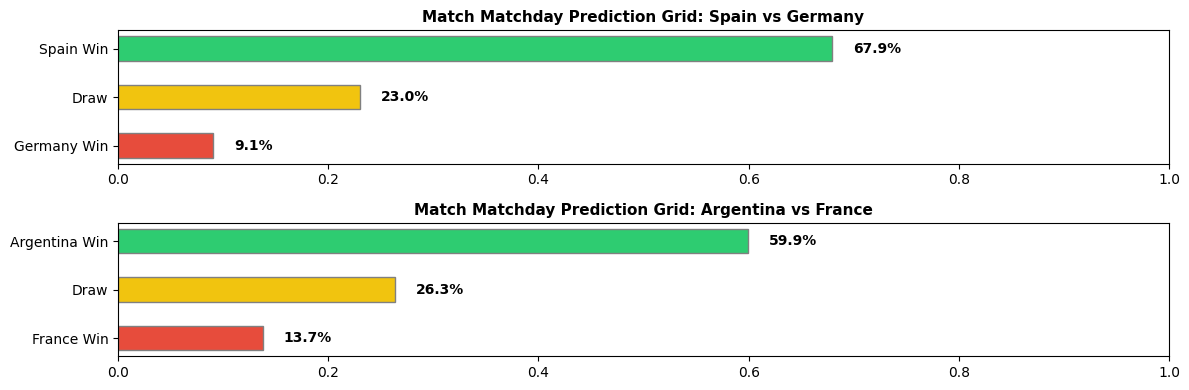

In [6]:
# ==========================================
# 6. RUNNING END-TO-END SIMULATION PIPELINE
# ==========================================
print("=== MEMULAI SIMULASI DATA SCIENCE UTALAH ===")

# Langkah 1: Tarik Data Historis & Data Mendatang Resmi FIFA
past_df = get_past_match_results(start_date="2022-01-01")
upcoming_df = get_upcoming_matches()

print(f"\n[Info] Berhasil memuat {len(past_df)} baris data historis.")
print(f"[Info] Berhasil memuat {len(upcoming_df)} jadwal laga mendatang.")

# Langkah 2: Bangun dataset training berbasis label historical data
past_df["outcome_label"] = past_df.apply(
    lambda r: 2 if r["home_score"] > r["away_score"] else (1 if r["home_score"] == r["away_score"] else 0),
    axis=1
)

# Hitung fitur historis untuk melatih model klasifikasi
training_features_df = generate_features(past_df, past_df)

# Langkah 3: Melatih Model Machine Learning Secara Lokal di Notebook
print("\n[Training] Melatih model RandomForest Outcome & Poisson Scoreline...")
outcome_model = MatchOutcomeModel()
outcome_model.train(training_features_df, past_df["outcome_label"])

score_model = ScorelineModel()
print("[Training] Model sukses dilatih.")

# Langkah 4: Hitung Fitur dan Jalankan Inferensi Prediksi pada Jadwal Laga Piala Dunia Terbaru
live_features_df = generate_features(upcoming_df, past_df)

# Jalankan Probabilitas Kemenangan
outcome_probs = outcome_model.predict_proba(live_features_df)
live_features_df["prob_away_win"] = outcome_probs[:, 0]
live_features_df["prob_draw"] = outcome_probs[:, 1]
live_features_df["prob_home_win"] = outcome_probs[:, 2]

# Jalankan Probabilitas Estimasi Gol Ekspektasi (xG)
pred_home_xg = []
pred_away_xg = []
for idx, row in live_features_df.iterrows():
    h_xg, a_xg = score_model.predict_expected_goals(row)
    pred_home_xg.append(h_xg)
    pred_away_xg.append(a_xg)

live_features_df["predicted_home_goals"] = pred_home_xg
live_features_df["predicted_away_goals"] = pred_away_xg

print("\n=== HASIL PREDIKSI DISIMPAN DALAM DATAFRAME ===")
display(live_features_df[["date", "home_team", "away_team", "prob_home_win", "prob_draw", "prob_away_win", "predicted_home_goals", "predicted_away_goals"]])

# Langkah 5: Tampilkan Grafik Prediksi Terupdate Langsung di Sini!
print("\n[Visualization] Menampilkan ringkasan probabilitas pertandingan terdekat:")
plot_notebook_predictions(live_features_df)

In [7]:
# ==========================================
# 7. INTERACTIVE SANDBOX (PLAYGROUND)
# ==========================================
# Di sel terakhir ini, Anda bisa bebas mengetik tim apa saja secara instan tanpa mengganggu pipeline utama!

def prediksi_laga_kustom(tim_kandang, tim_tandang):
    mock_match = pd.DataFrame([{"match_id": "manual_test", "date": datetime.now(), "home_team": tim_kandang, "away_team": tim_tandang}])
    features_mock = generate_features(mock_match, past_df)
    
    # Hitung probabilitas
    prob = outcome_model.predict_proba(features_mock)[0]
    h_xg, a_xg = score_model.predict_expected_goals(features_mock.iloc[0])
    matrix_skor = score_model.predict_score_probabilities(features_mock.iloc[0])
    skor_terpopuler = sorted(matrix_skor.items(), key=lambda x: x[1], reverse=True)[:3]
    
    print(f"🔮 PREDIKSI KUSTOM: {tim_kandang} vs {tim_tandang} 🔮")
    print("-" * 45)
    print(f"Peluang {tim_kandang} Menang : {prob[2]:.1%}")
    print(f"Peluang Hasil Seri      : {prob[1]:.1%}")
    print(f"Peluang {tim_tandang} Menang : {prob[0]:.1%}")
    print(f"Ekspektasi Gol (xG)     : {tim_kandang} ({h_xg:.2f}) vs {tim_tandang} ({a_xg:.2f})")
    print("\n3 Prediksi Skor Paling Memungkinkan:")
    for skor, p in skor_terpopuler:
        print(f" - Skor {skor} | Probabilitas: {p:.1%}")

# SILAKAN UBAH NAMA TIM DI BAWAH INI UNTUK BERMAIN-MAIN:
prediksi_laga_kustom("Brazil", "Argentina")

🔮 PREDIKSI KUSTOM: Brazil vs Argentina 🔮
---------------------------------------------
Peluang Brazil Menang : 23.2%
Peluang Hasil Seri      : 29.2%
Peluang Argentina Menang : 47.7%
Ekspektasi Gol (xG)     : Brazil (1.10) vs Argentina (1.30)

3 Prediksi Skor Paling Memungkinkan:
 - Skor 1-1 | Probabilitas: 13.0%
 - Skor 0-1 | Probabilitas: 11.8%
 - Skor 1-0 | Probabilitas: 10.0%
